In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import time
import scienceplots
plt.style.use(['science','grid'])

### Simulate the stifness coefficients as lognormal random fields

In [3]:
#plotting utility function
def pcolor_plot(AX, X, Y, C, title,colormap="viridis",set_axis = 'off',**kwargs):
    ## plot the pcolor plot of the given data C on the given axis AX with the given title and optional colorbar limits cmin and cmax
    if len(kwargs) == 0:
        im = AX.pcolor(X, Y, C, cmap=colormap,shading='auto')
    else:
        cmin = kwargs["cmin"]
        cmax = kwargs["cmax"]
        im = AX.pcolor(X, Y, C, cmap=colormap, vmin=cmin, vmax=cmax,shading='auto')
    AX.set_aspect("equal", "box")
    AX.axis("off")
    AX.set_title(title, fontsize=14)
    return im

## Implementation of the PINN-PC framework

In [12]:
# The code has been tested with both JAX and PyTorch backends. It should work with TensorFlow/Paddle as well but has not been tested.
# JAX is recommended for higher computational performance (x10-x20 faster than PyTorch in our implementation).
import deepxde as dde
import jax.numpy as jnp

# Define functions
sin = dde.backend.sin
cos = dde.backend.cos
stack = dde.backend.stack

net_type = ["spinn","pinn"][0]
Lmax = 100.0
pstress = 0.1

# Material parameters: [mu, sigma, bx, by]
# C11param = [1.55, 0.129, 20.18, 16.6]   
# C33param = [0.316, 0.027, 20.86, 15.08] --> from original paper
C11param = [1.55, 0.129, 50, 50] 
C33param = [0.316, 0.027, 50, 50] # --> increase spatial correlation to limit number KL terms

# Compute Lamé parameters
lmbd = np.exp(C11param[0]) - 2 * np.exp(C33param[0])
mu = np.exp(C33param[0])

E = 9*mu*(lmbd + mu)/(3*lmbd + 3*mu)
nu = lmbd/(lmbd + 2*mu)

Exx_mean = pstress/E
Eyy_mean = -Exx_mean*nu

Exx_mean_fem = 0.02571187493951528
Eyy_mean_fem = -0.010741097568904246

def transform_coords(x):
    """
    For SPINN, if the input x is provided as a list of 1D arrays (e.g., [X_coords, Y_coords]),
    this function creates a 2D meshgrid and stacks the results into a 2D coordinate array.
    """
    x_mesh = [x_.ravel() for x_ in jnp.meshgrid(jnp.atleast_1d(x[0].squeeze()), jnp.atleast_1d(x[1].squeeze()), indexing="ij")]
    return dde.backend.stack(x_mesh, axis=-1)

def solution_fn(x):
    if net_type == "spinn":
        x = transform_coords(x)
    Ux = Exx_mean_fem*x[:,0]
    Uy = Eyy_mean_fem*x[:,1]
    return np.stack([Ux,Uy],axis=1)

print(f"Ux_max/Ux_max_fem = {Exx_mean:0.4f}/{Exx_mean_fem:0.4f}")
print(f"Uy_min/Uy_min_fem = {Eyy_mean:0.4f}/{Eyy_mean_fem:0.4f}")
print(f"nu/nu_fem = {nu:0.4f}/{-Eyy_mean_fem/Exx_mean_fem:0.4f}")

Ux_max/Ux_max_fem = 0.0243/0.0257
Uy_min/Uy_min_fem = -0.0102/-0.0107
nu/nu_fem = 0.4177/0.4177


In [13]:
geom = dde.geometry.Rectangle([0, 0], [Lmax, Lmax])
BC_type = ["hard", "soft"][0]
coord_normalization = True
# x_max = 1.0 if coord_normalization else Lmax
num_bc_points = 25

bc_linspace = np.linspace(0, Lmax, num_bc_points).reshape(-1,1)
if net_type != "spinn":
    bc_0 = np.zeros_like(bc_linspace)
    bc_Lmax = Lmax*np.ones_like(bc_linspace)
else:
    bc_0 = np.array([0]).reshape(-1,1)
    bc_Lmax = np.array([Lmax]).reshape(-1,1)

bc_point_left = [bc_0, bc_linspace]
bc_point_right = [bc_Lmax, bc_linspace]
bc_point_bottom = [bc_linspace, bc_0]
bc_point_top = [bc_linspace, bc_Lmax]

if net_type != "spinn":
    bc_point_left = np.hstack(bc_point_left)
    bc_point_right = np.hstack(bc_point_right)
    bc_point_bottom = np.hstack(bc_point_bottom)
    bc_point_top = np.hstack(bc_point_top)

bc_point_all = [bc_point_left, bc_point_right, bc_point_bottom, bc_point_top]

# Soft Boundary Conditions
def S_from_output(x, f,X):
    if net_type == "spinn":
        x = transform_coords(x)
    E_xx = dde.grad.jacobian(f, x, i=0, j=0)[0]
    E_yy = dde.grad.jacobian(f, x, i=1, j=1)[0]
    E_xy = 0.5 * (dde.grad.jacobian(f, x, i=0, j=1)[0] + dde.grad.jacobian(f, x, i=1, j=0)[0])

    S_xx = E_xx * (2 * mu + lmbd) + E_yy * lmbd
    S_yy = E_yy * (2 * mu + lmbd) + E_xx * lmbd
    S_xy = E_xy * 2 * mu

    return stack((S_xx, S_yy, S_xy), axis=1)

ux_left_bc = dde.PointSetOperatorBC(bc_point_left,0,lambda x, f, X: f[:, 0])
uy_bottom_bc = dde.PointSetOperatorBC(bc_point_bottom,0,lambda x, f, X: f[:, 1])
sxx_right_bc = dde.PointSetOperatorBC(bc_point_right,0,lambda x, f, X: S_from_output(x, f, X)[:, 0:1]-pstress)
syy_top_bc = dde.PointSetOperatorBC(bc_point_top,0,lambda x, f, X: S_from_output(x, f, X)[:, 1:2])
sxy_bc = [dde.PointSetOperatorBC(bc_point,0,lambda x, f, X: S_from_output(x, f, X)[:, 2]) for bc_point in bc_point_all]

bcs = [ux_left_bc, uy_bottom_bc] if BC_type == "soft" else []
bcs += [sxx_right_bc,syy_top_bc]
bcs += sxy_bc

# Hard Boundary Conditions
def hard_BC(x, f):
    if isinstance(x, list) and net_type == "spinn":
        x = transform_coords(x)
    Ux = f[:, 0] * x[:, 0] 
    Uy = f[:, 1] * x[:, 1] 
    return stack((Ux, Uy), axis=1)

def pde(x, f):
    if net_type == "spinn":
        x = transform_coords(x)
    E_xx = dde.grad.jacobian(f, x, i=0, j=0)
    E_yy = dde.grad.jacobian(f, x, i=1, j=1)
    E_xy = (0.5 * (dde.grad.jacobian(f, x, i=0, j=1)[0] + dde.grad.jacobian(f, x, i=1, j=0)[0]), lambda x: 0.5 * (dde.grad.jacobian(f, x.reshape(1,-1), i=0, j=1)[1](x) + dde.grad.jacobian(f, x.reshape(1,-1), i=1, j=0)[1](x))) 

    S_xx = (E_xx[0] * (2 * mu + lmbd) + E_yy[0] * lmbd, lambda x: E_xx[1](x) * (2 * mu + lmbd) + E_yy[1](x) * lmbd)
    S_yy = (E_yy[0] * (2 * mu + lmbd) + E_xx[0] * lmbd, lambda x: E_yy[1](x) * (2 * mu + lmbd) + E_xx[1](x) * lmbd)
    S_xy = (E_xy[0] * 2 * mu, lambda x: E_xy[1](x) * 2 * mu)

    Sxx_x = dde.grad.jacobian(S_xx, x, i=0, j=0)[0]
    Syy_y = dde.grad.jacobian(S_yy, x, i=0, j=1)[0]
    Sxy_x = dde.grad.jacobian(S_xy, x, i=0, j=0)[0]
    Sxy_y = dde.grad.jacobian(S_xy, x, i=0, j=1)[0]

    momentum_x = Sxx_x + Sxy_y
    momentum_y = Sxy_x + Syy_y

    return [momentum_x, momentum_y]

In [14]:
data = dde.data.PDE(
    geom,
    pde,
    bcs,
    num_domain=1000 if net_type == "spinn" else 500,
    num_boundary=0,
    solution=solution_fn,
    num_test=100,
    is_SPINN=(net_type == "spinn"),
)

activation = "tanh"
initializer = "Glorot uniform"
if net_type == "spinn":
    layers = [2] + [32] * 3 + [2]
    net = dde.nn.SPINN(layers, activation, initializer)
else:
    layers = [2, [40] * 2, [40] * 2, [40] * 2, [40] * 2, 2]
    net = dde.nn.PFNN(layers, activation, initializer)


def input_scaling(x):
    """
    Scale the input coordinates to the range [0, 1].
    """
    if isinstance(x, list):
        return [x_el / Lmax for x_el in x]
    else:
        return x / Lmax
    
if BC_type == "hard":
    net.apply_output_transform(hard_BC)
if coord_normalization:
    net.apply_feature_transform(input_scaling)

model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"], loss_weights=[1]*8)

Compiling model...
'compile' took 0.226577 s



In [15]:
from jax.flatten_util import ravel_pytree
import jax

X_input = [np.linspace(0, Lmax, 100).reshape(-1, 1)] * 2
X_mesh, Y_mesh = np.meshgrid(X_input[0], X_input[1])
if net_type != "spinn":
    X_input = np.vstack((X_mesh.flatten(), Y_mesh.flatten())).T
    
def loss_function(params,comp=0,inputs=[bc_point_right]+[bc_point_top]+bc_point_all+[X_input]):
    return model.outputs_losses_train(params, inputs, None)[1][comp]

n_loss = len(model.loss_weights)

def calc_loss_weights(model):
    loss_grads = [1]*n_loss

    for i in range(n_loss):
        grad_fn = jax.grad(lambda params,comp=i: loss_function(params,comp))
        grads = grad_fn(model.params)[0]
        flattened_grad = ravel_pytree(list(grads.values())[0])[0]
        loss_grads[i] = jnp.linalg.norm(flattened_grad)

    loss_grads = jnp.array(loss_grads)
    loss_weights_grads = jnp.sum(loss_grads)/loss_grads # Caution: ad-hoc sqrt
    return loss_weights_grads, loss_grads

loss_weights_grads, loss_grads = calc_loss_weights(model)
new_loss_weights = [w * g for w, g in zip(model.loss_weights, loss_weights_grads)]
model.compile("adam", lr=0.001, metrics=["l2 relative error"],
              loss_weights=new_loss_weights)

Compiling model...
'compile' took 0.096267 s



In [8]:
losshistory, train_state = model.train(iterations=5000, display_every=200)

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric   
0         [9.04e-04, 4.55e-04, 1.20e-02, 6.36e-05, 6.92e-04, 1.41e-03, 1.49e-03, 1.49e-03]    [8.85e-04, 4.44e-04, 1.20e-02, 6.36e-05, 6.92e-04, 1.41e-03, 1.49e-03, 1.49e-03]    [1.04e+00]    
200       [3.62e-05, 6.44e-05, 1.17e-03, 6.98e-05, 3.62e-05, 3.26e-05, 1.89e-04, 7.13e-05]    [2.84e-05, 6.02e-05, 1.17e-03, 6.98e-05, 3.62e-05, 3.26e-05, 1.89e-04, 7.13e-05]    [3.49e-01]    
400       [2.14e-05, 8.30e-06, 2.23e-07, 1.85e-06, 1.88e-06, 4.54e-06, 1.31e-06, 1.67e-06]    [1.70e-05, 6.81e-06, 2.23e-07, 1.85e-06, 1.88e-06, 4.54e-06, 1.31e-06, 1.67e-06]    [8.03e-03]    
600       [1.22e-05, 6.69e-06, 4.64e-07, 1.08e-05, 9.94e-07, 2.73e-06, 1.02e-06, 1.07e-06]    [1.08e-05, 5.28e-06, 4.64e-07, 1.08e-05, 9.94e-07, 2.73e-06, 1.02e-06, 1.07e-06]    [7.40e-03]    
800       [8.67e

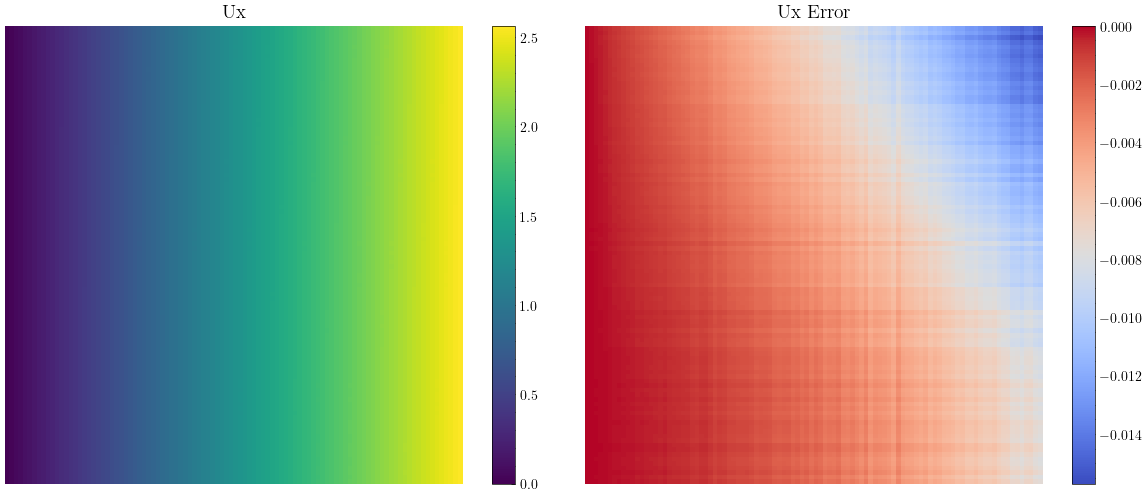

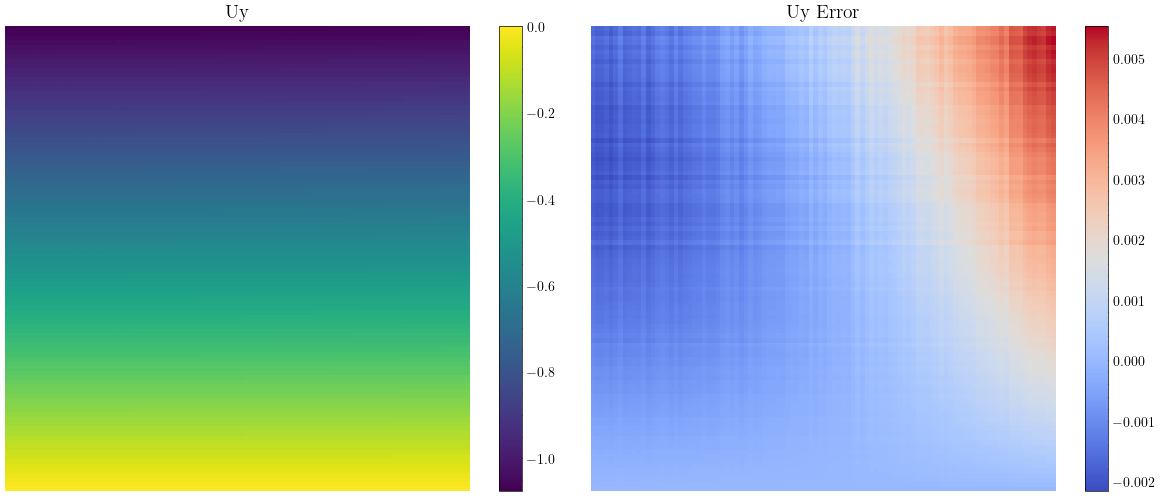

In [11]:
X_input = [np.linspace(0, Lmax, 100).reshape(-1, 1)] * 2
X_mesh, Y_mesh = np.meshgrid(X_input[0], X_input[1])
if net_type != "spinn":
    X_input = np.vstack((X_mesh.flatten(), Y_mesh.flatten())).T
Y_pred = model.predict([X_input])
Ux_pred = Y_pred[:, 0].reshape(X_mesh.shape).T
Uy_pred = Y_pred[:, 1].reshape(X_mesh.shape).T

Ux_true = solution_fn(X_input)[:,0].reshape(X_mesh.shape).T
Uy_true = solution_fn(X_input)[:,1].reshape(X_mesh.shape).T

fig,ax = plt.subplots(1, 2, figsize=(12, 5))
im = pcolor_plot(ax[0], X_mesh, Y_mesh, Ux_pred, "Ux")
fig.colorbar(im, ax=ax[0])
im = pcolor_plot(ax[1], X_mesh, Y_mesh, Ux_pred - Ux_true, "Ux Error",colormap="coolwarm")#,cmin=-0.1,cmax=0.1)
fig.colorbar(im, ax=ax[1])
fig.tight_layout()

fig,ax = plt.subplots(1, 2, figsize=(12, 5))
im = pcolor_plot(ax[0], X_mesh, Y_mesh, Uy_pred, "Uy")
fig.colorbar(im, ax=ax[0])
im = pcolor_plot(ax[1], X_mesh, Y_mesh, Uy_pred - Uy_true, "Uy Error",colormap="coolwarm")#,cmin=-0.1,cmax=0.1)
fig.colorbar(im, ax=ax[1])
fig.tight_layout()


## Space varrying material properties

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import time
import scienceplots
plt.style.use(['science','grid'])

In [109]:
def correlation_function(distance,i=2):
    """Exponential correlation function."""
    return np.exp(-distance**i)

def compute_correlation_matrix(grid,kernel, bx,by):
    """Compute the correlation matrix for a 2D grid."""
    N = grid.shape[0]
    C = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            d = np.sqrt(((grid[i, 0] - grid[j, 0])/bx)**2 + ((grid[i, 1] - grid[j, 1])/by)**2)
            C[i, j] = kernel(d)
    return C


def KL_expansion(grid, kernel, C_param,truncation_order):
    """Compute the KL expansion."""
    N = grid.shape[0]
    mu = C_param[0]
    sigma = C_param[1]
    bx = C_param[2]
    by = C_param[3]
    C = compute_correlation_matrix(grid, kernel, bx, by)
    eig_values, eig_vectors = np.linalg.eigh(C)
    # Sort eigenvalues and eigenvectors
    idx = eig_values.argsort()[::-1]
    eig_values = eig_values[idx]
    eig_vectors = eig_vectors[:, idx]

    return eig_values[:truncation_order], eig_vectors[:, :truncation_order]

C11param = [ 1.55, 0.129, 50, 50]   # = [ mu, sigma , bx, by] 
C33param = [ 0.316, 0.027, 50, 50]

# Parameters
N = 27
Lmax = 100

# Create 2D grid
x = np.linspace(0, Lmax, N)
y = np.linspace(0, Lmax, N)
X, Y = np.meshgrid(x, y)
grid = np.column_stack((X.ravel(), Y.ravel()))

# Spectral decomposition
eig_values_C11, eig_vectors_C11 = KL_expansion(grid, correlation_function, C11param, N**2)
eig_values_C33, eig_vectors_C33 = KL_expansion(grid, correlation_function, C33param, N**2)

The 8 first modes explain 95.00% of the variance.


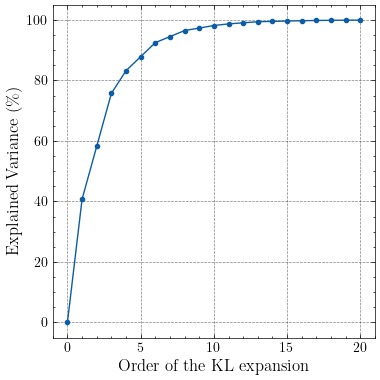

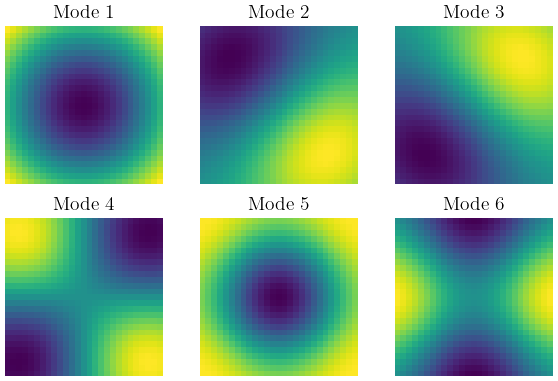

In [110]:
#Truncation of the KL expansion based on the explained variance

explained_variance = np.cumsum(eig_values_C11) / np.sum(eig_values_C11)
fig = plt.figure(figsize=(4, 4))
n_orders = 20
plt.plot(np.arange(0, n_orders + 1), [0] + list(explained_variance[:n_orders]*100), marker='.')
plt.xlabel(r'Order of the KL expansion', fontsize=12)
plt.ylabel(r'Explained Variance (\%)', fontsize=12)
# plt.title('Explained Variance vs. Order of KL Expansion')
plt.tight_layout()
fig.savefig('figures/KL_explained_variance_C11.pdf')

# Propose truncation order based on a threshold
threshold = 0.95  # Example threshold for 99% explained variance
truncation_order = np.argmax(explained_variance >= threshold) + 1
print(f"The {truncation_order} first modes explain {threshold*100:.2f}% of the variance.")

# Plot first modes
fig, ax = plt.subplots(2, 3, figsize=(6, 4))
for i in range(6):
    im = pcolor_plot(ax.flatten()[i], X, Y, eig_vectors_C11[:, i].reshape((27,27)), f"Mode {i+1}")
plt.tight_layout()
# plt.suptitle('First 8 Modes of the KL Expansion for C11', fontsize=20, y=1.15)
fig.savefig('figures/KL_modes_C11.pdf')


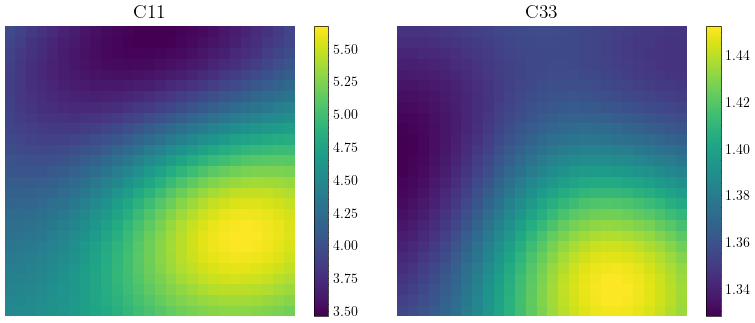

In [111]:
# Simulate Gaussian Random Field using K-L expansion
def C_from_xi(xi, eig_values, eig_vectors, C_param):
    """Compute the Gaussian Random Field from the KL expansion."""
    N = int(np.sqrt(eig_vectors.shape[0]))
    Nsim = xi.shape[0]
    XC = eig_vectors @ (np.sqrt(eig_values) * xi).T
    C = np.exp(C_param[0] + C_param[1] * XC)
    C = C.reshape((N, N, Nsim))
    return C

def dC_from_xi(xi, eig_values, eig_vectors, eig_vectors_dx, eig_vectors_dy, C_param):
    """Compute the gradient of the Gaussian Random Field from the KL expansion."""
    N = int(np.sqrt(eig_vectors.shape[0]))
    Nsim = xi.shape[0]
    XC = eig_vectors @ (np.sqrt(eig_values) * xi).T
    dXC_dx = eig_vectors_dx @ (np.sqrt(eig_values) * xi).T
    dXC_dy = eig_vectors_dy @ (np.sqrt(eig_values) * xi).T
    dC_dx = C_param[1] * dXC_dx * np.exp(C_param[0] + C_param[1] * XC)
    dC_dy = C_param[1] * dXC_dy * np.exp(C_param[0] + C_param[1] * XC)
    return dC_dx.reshape((N, N, Nsim)), dC_dy.reshape((N, N, Nsim))

# Spectral decomposition
eig_values_C11, eig_vectors_C11 = KL_expansion(grid, correlation_function, C11param, truncation_order)
eig_values_C33, eig_vectors_C33 = KL_expansion(grid, correlation_function, C33param, truncation_order)

U_C11 = np.random.randn(1,truncation_order)
U_C33 = np.random.randn(1,truncation_order)

# Compute random coefficients
C11 = C_from_xi(U_C11, eig_values_C11, eig_vectors_C11, C11param)
C33 = C_from_xi(U_C33, eig_values_C33, eig_vectors_C33, C33param)

# Visualization
fig,ax = plt.subplots(1,2,figsize=(8,3.3))

imC11 = pcolor_plot(ax[0], X, Y, C11[:,:,0], "C11")
fig.colorbar(imC11, ax=ax[0])
imC33 = pcolor_plot(ax[1], X, Y, C33[:,:,0], "C33")
fig.colorbar(imC33, ax=ax[1])
plt.tight_layout()

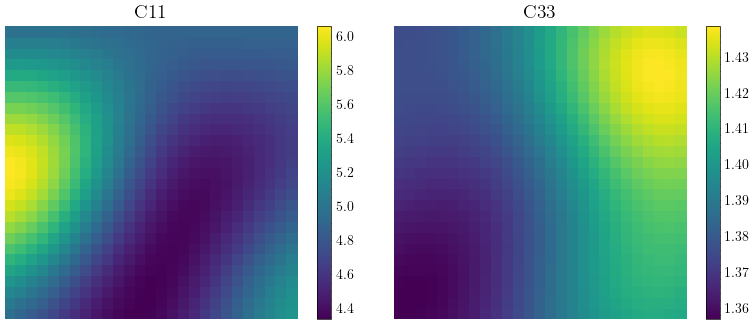

In [112]:
# Simulate Gaussian Random Field using K-L expansion
def C_from_xi(xi, eig_values, eig_vectors, C_param):
    """Compute the Gaussian Random Field from the KL expansion."""
    N = int(np.sqrt(eig_vectors.shape[0]))
    Nsim = xi.shape[0]
    XC = eig_vectors @ (np.sqrt(eig_values) * xi).T
    C = np.exp(C_param[0] + C_param[1] * XC)
    C = C.reshape((N, N, Nsim))
    return C

def dC_from_xi(xi, eig_values, eig_vectors, eig_vectors_dx, eig_vectors_dy, C_param):
    """Compute the gradient of the Gaussian Random Field from the KL expansion."""
    N = int(np.sqrt(eig_vectors.shape[0]))
    Nsim = xi.shape[0]
    XC = eig_vectors @ (np.sqrt(eig_values) * xi).T
    dXC_dx = eig_vectors_dx @ (np.sqrt(eig_values) * xi).T
    dXC_dy = eig_vectors_dy @ (np.sqrt(eig_values) * xi).T
    dC_dx = C_param[1] * dXC_dx * np.exp(C_param[0] + C_param[1] * XC)
    dC_dy = C_param[1] * dXC_dy * np.exp(C_param[0] + C_param[1] * XC)
    return dC_dx.reshape((N, N, Nsim)), dC_dy.reshape((N, N, Nsim))

# Spectral decomposition
eig_values_C11, eig_vectors_C11 = KL_expansion(grid, correlation_function, C11param, truncation_order)
eig_values_C33, eig_vectors_C33 = KL_expansion(grid, correlation_function, C33param, truncation_order)

U_C11 = np.random.randn(1,truncation_order)
U_C33 = np.random.randn(1,truncation_order)

# Compute random coefficients
C11 = C_from_xi(U_C11, eig_values_C11, eig_vectors_C11, C11param)
C33 = C_from_xi(U_C33, eig_values_C33, eig_vectors_C33, C33param)

# Visualization
fig,ax = plt.subplots(1,2,figsize=(8,3.3))

imC11 = pcolor_plot(ax[0], X, Y, C11[:,:,0], "C11")
fig.colorbar(imC11, ax=ax[0])
imC33 = pcolor_plot(ax[1], X, Y, C33[:,:,0], "C33")
fig.colorbar(imC33, ax=ax[1])
plt.tight_layout()

In [113]:
# The code has been tested with both JAX and PyTorch backends. It should work with TensorFlow/Paddle as well but has not been tested.
# JAX is recommended for higher computational performance (x10-x20 faster than PyTorch in our implementation).
import deepxde as dde
from jax.scipy.interpolate import RegularGridInterpolator

# Define functions
sin = dde.backend.sin
cos = dde.backend.cos
stack = dde.backend.stack

net_type = ["spinn","pinn"][0]
Lmax = 100.0
pstress = 0.1

n_xi_samples = 1000
n_xi_batch = 100
truncation_order = 8

# Simulate Gaussian Random Field using K-L expansion
U_C11 = np.random.randn(n_xi_samples,truncation_order)
U_C33 = np.random.randn(n_xi_samples,truncation_order)
xi_train = np.concatenate([U_C11,U_C33],axis=1)


# Compute random coefficients
C11 = C_from_xi(U_C11, eig_values_C11, eig_vectors_C11, C11param)
C33 = C_from_xi(U_C33, eig_values_C33, eig_vectors_C33, C33param)

X_interp = np.linspace(0, Lmax, N)
Y_interp = np.linspace(0, Lmax, N)
# create C interpolation function
def create_interpolation_fn(data_array):
    return RegularGridInterpolator((X_interp, Y_interp), data_array)

C11_fun = [create_interpolation_fn(C11[:,:,i]) for i in range(n_xi_samples)]
C33_fun = [create_interpolation_fn(C33[:,:,i]) for i in range(n_xi_samples)]

Exx_mean_fem = 0.09937324349011243
Eyy_mean_fem = -.05885460477883619

def transform_coords(x):
    """
    For SPINN, if the input x is provided as a list of 1D arrays (e.g., [X_coords, Y_coords]),
    this function creates a 2D meshgrid and stacks the results into a 2D coordinate array.
    """
    x_mesh = [x_.ravel() for x_ in jnp.meshgrid(jnp.atleast_1d(x[0].squeeze()), jnp.atleast_1d(x[1].squeeze()), indexing="ij")]
    return dde.backend.stack(x_mesh, axis=-1)

def solution_fn(x):
    if net_type == "spinn":
        x = transform_coords(x)
    Ux = Exx_mean_fem*x[:,0]
    Uy = Eyy_mean_fem*x[:,1]
    return np.stack([Ux,Uy],axis=1)

def extract_from_output(f,variable, mean_or_coefs):
    """
    net output columns: Ux_mean, Ux_coefs, Uy_mean, Uy_coefs
    mean of size 1 and coefs of size truncation_order
    """
    i_begin = 0 if mean_or_coefs == "mean" else 1
    i_end = 1 if mean_or_coefs == "mean" else truncation_order

    if variable == "Uy":
        i_begin += truncation_order
        i_end += truncation_order
    return (f[0][:,i_begin:i_end], lambda x: f[1](x)[:,i_begin:i_end])

In [152]:
geom = dde.geometry.Rectangle([0, 0], [Lmax, Lmax])
BC_type = ["hard", "soft"][0]
coord_normalization = True
# x_max = 1.0 if coord_normalization else Lmax
num_bc_points = 25

bc_linspace = np.linspace(0, Lmax, num_bc_points).reshape(-1,1)
if net_type != "spinn":
    bc_0 = np.zeros_like(bc_linspace)
    bc_Lmax = Lmax*np.ones_like(bc_linspace)
else:
    bc_0 = np.array([0]).reshape(-1,1)
    bc_Lmax = np.array([Lmax]).reshape(-1,1)

bc_point_left = [bc_0, bc_linspace]
bc_point_right = [bc_Lmax, bc_linspace]
bc_point_bottom = [bc_linspace, bc_0]
bc_point_top = [bc_linspace, bc_Lmax]

if net_type != "spinn":
    bc_point_left = np.hstack(bc_point_left)
    bc_point_right = np.hstack(bc_point_right)
    bc_point_bottom = np.hstack(bc_point_bottom)
    bc_point_top = np.hstack(bc_point_top)

bc_point_all = [bc_point_left, bc_point_right, bc_point_bottom, bc_point_top]

# Soft Boundary Conditions
def S_from_output(x, f,X):
    if net_type == "spinn":
        x = transform_coords(x)

    lmbd = C11_fun[0](x).reshape(-1,1) - 2*C33_fun[0](x).reshape(-1,1)
    mu = C33_fun[0](x).reshape(-1,1)

    E_xx = dde.grad.jacobian(f, x, i=0, j=0)[0]
    E_yy = dde.grad.jacobian(f, x, i=1, j=1)[0]
    E_xy = 0.5 * (dde.grad.jacobian(f, x, i=0, j=1)[0] + dde.grad.jacobian(f, x, i=1, j=0)[0])

    S_xx = E_xx * (2 * mu + lmbd) + E_yy * lmbd
    S_yy = E_yy * (2 * mu + lmbd) + E_xx * lmbd
    S_xy = E_xy * 2 * mu

    return stack((S_xx, S_yy, S_xy), axis=1)

ux_left_bc = dde.PointSetOperatorBC(bc_point_left,0,lambda x, f, X: f[:, 0])
uy_bottom_bc = dde.PointSetOperatorBC(bc_point_bottom,0,lambda x, f, X: f[:, 1])
sxx_right_bc = dde.PointSetOperatorBC(bc_point_right,0,lambda x, f, X: S_from_output(x, f, X)[:, 0:1]-pstress)
syy_top_bc = dde.PointSetOperatorBC(bc_point_top,0,lambda x, f, X: S_from_output(x, f, X)[:, 1:2])
sxy_bc = [dde.PointSetOperatorBC(bc_point,0,lambda x, f, X: S_from_output(x, f, X)[:, 2]) for bc_point in bc_point_all]

bcs = [ux_left_bc, uy_bottom_bc] if BC_type == "soft" else []
bcs += [sxx_right_bc,syy_top_bc]
bcs += sxy_bc

# Hard Boundary Conditions
def hard_BC(x, f):
    if isinstance(x, list) and net_type == "spinn":
        x = transform_coords(x)
    Ux = f[:, 0] * x[:, 0] 
    Uy = f[:, 1] * x[:, 1] 
    return stack((Ux, Uy), axis=1)

def pde(x, f):
    if net_type == "spinn":
        x = transform_coords(x)
    
    lmbd = C11_fun[0](x).reshape(-1,1) - 2*C33_fun[0](x).reshape(-1,1)
    mu = C33_fun[0](x).reshape(-1,1)

    E_xx = dde.grad.jacobian(f, x, i=0, j=0)
    E_yy = dde.grad.jacobian(f, x, i=1, j=1)
    E_xy = (0.5 * (dde.grad.jacobian(f, x, i=0, j=1)[0] + dde.grad.jacobian(f, x, i=1, j=0)[0]), lambda x: 0.5 * (dde.grad.jacobian(f, x.reshape(1,-1), i=0, j=1)[1](x) + dde.grad.jacobian(f, x.reshape(1,-1), i=1, j=0)[1](x))) 

    S_xx_val = (E_xx[0] * (2 * mu + lmbd) + E_yy[0] * lmbd).squeeze()
    S_yy_val = (E_yy[0] * (2 * mu + lmbd) + E_xx[0] * lmbd).squeeze()
    S_xy_val = (E_xy[0] * 2 * mu).squeeze()

    S_xx = (E_xx[0] * (2 * mu + lmbd) + E_yy[0] * lmbd, lambda x: E_xx[1](x) * (2 * mu + lmbd) + E_yy[1](x) * lmbd)
    S_yy = (E_yy[0] * (2 * mu + lmbd) + E_xx[0] * lmbd, lambda x: E_yy[1](x) * (2 * mu + lmbd) + E_xx[1](x) * lmbd)
    S_xy = (E_xy[0] * 2 * mu, lambda x: E_xy[1](x) * 2 * mu)


    Sxx_x = dde.grad.jacobian(S_xx, x, i=0, j=0)[0]
    Syy_y = dde.grad.jacobian(S_yy, x, i=0, j=1)[0]
    Sxy_x = dde.grad.jacobian(S_xy, x, i=0, j=0)[0]
    Sxy_y = dde.grad.jacobian(S_xy, x, i=0, j=1)[0]

    momentum_x = Sxx_x + Sxy_y
    momentum_y = Sxy_x + Syy_y

    return [momentum_x, momentum_y]

In [150]:
data = dde.data.PDE(
    geom,
    pde,
    bcs,
    num_domain=1000 if net_type == "spinn" else 500,
    num_boundary=0,
    solution=solution_fn,
    num_test=100,
    is_SPINN=(net_type == "spinn"),
)

activation = "tanh"
initializer = "Glorot uniform"
if net_type == "spinn":
    layers = [2] + [32] * 3 + [2]
    net = dde.nn.SPINN(layers, activation, initializer)
else:
    layers = [2, [40] * 2, [40] * 2, [40] * 2, [40] * 2, 2]
    net = dde.nn.PFNN(layers, activation, initializer)


def input_scaling(x):
    """
    Scale the input coordinates to the range [0, 1].
    """
    if isinstance(x, list):
        return [x_el / Lmax for x_el in x]
    else:
        return x / Lmax
    
if BC_type == "hard":
    net.apply_output_transform(hard_BC)
if coord_normalization:
    net.apply_feature_transform(input_scaling)

model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"], loss_weights=[1]*8)

Compiling model...
'compile' took 0.090068 s



In [139]:
from jax.flatten_util import ravel_pytree
import jax

X_input = [np.linspace(0, Lmax, 100).reshape(-1, 1)] * 2
X_mesh, Y_mesh = np.meshgrid(X_input[0], X_input[1])
if net_type != "spinn":
    X_input = np.vstack((X_mesh.flatten(), Y_mesh.flatten())).T
    
def loss_function(params,comp=0,inputs=[bc_point_right]+[bc_point_top]+bc_point_all+[X_input]):
    return model.outputs_losses_train(params, inputs, None)[1][comp]

n_loss = len(model.loss_weights)

def calc_loss_weights(model):
    loss_grads = [1]*n_loss

    for i in range(n_loss):
        grad_fn = jax.grad(lambda params,comp=i: loss_function(params,comp))
        grads = grad_fn(model.params)[0]
        flattened_grad = ravel_pytree(list(grads.values())[0])[0]
        loss_grads[i] = jnp.linalg.norm(flattened_grad)

    loss_grads = jnp.array(loss_grads)
    loss_weights_grads = jnp.sum(loss_grads)/loss_grads # Caution: ad-hoc sqrt
    return loss_weights_grads, loss_grads

loss_weights_grads, loss_grads = calc_loss_weights(model)
new_loss_weights = [w * g for w, g in zip(model.loss_weights, loss_weights_grads)]
model.compile("adam", lr=0.001, metrics=["l2 relative error"],
              loss_weights=new_loss_weights)

TypeError: Gradient only defined for scalar-output functions. Output had shape: (1,).

In [ ]:
losshistory, train_state = model.train(iterations=5000, display_every=200)s

Training model...



IndexError: tuple index out of range

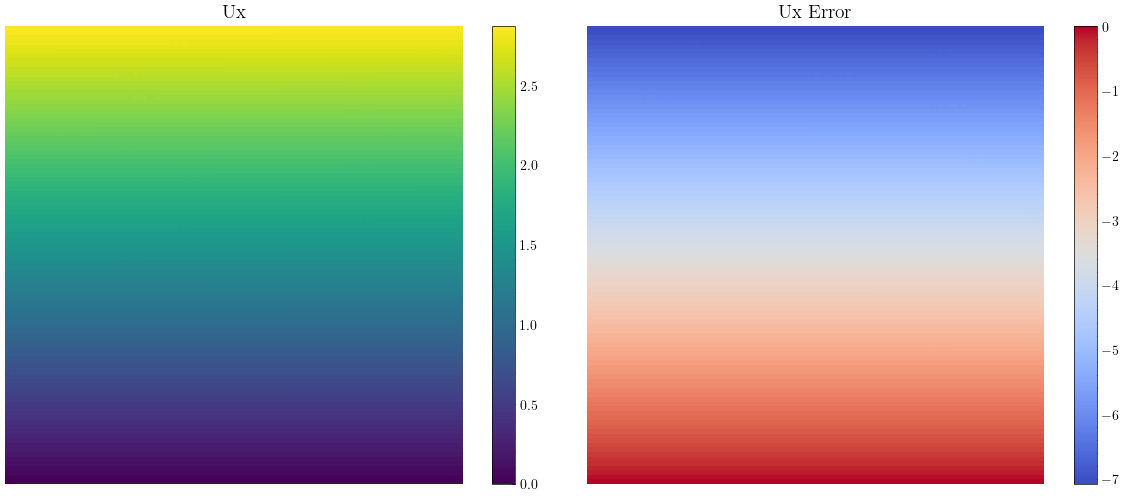

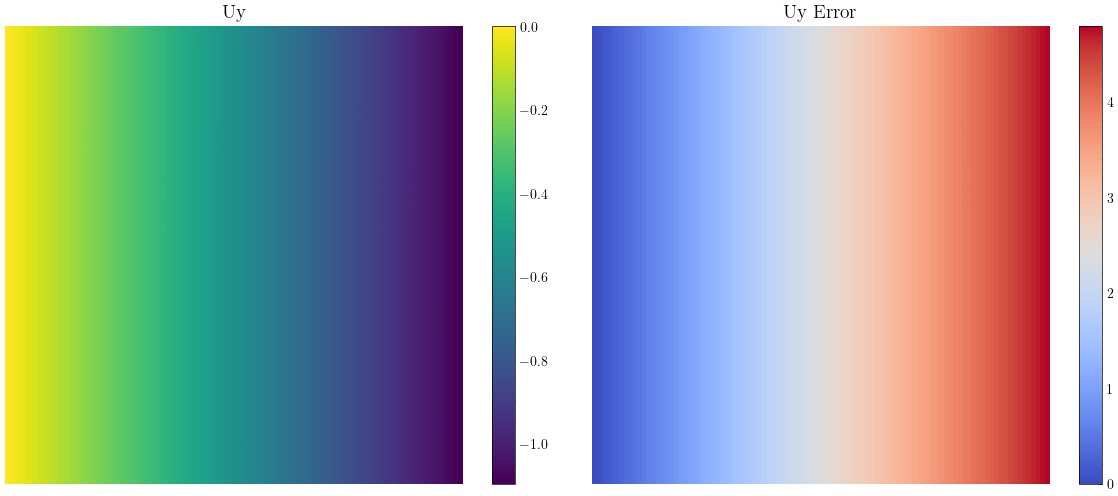

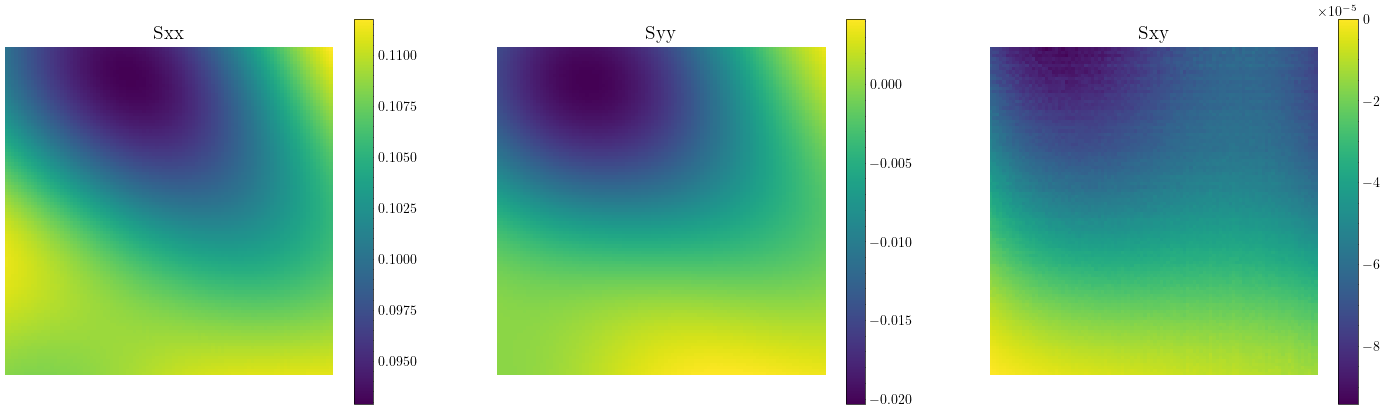

In [133]:
X_input = [np.linspace(0, Lmax, 100).reshape(-1, 1)] * 2
X_mesh, Y_mesh = np.meshgrid(X_input[0], X_input[1])
if net_type != "spinn":
    X_input = np.vstack((X_mesh.flatten(), Y_mesh.flatten())).T
Y_pred = model.predict([X_input])
Y_pred_fun = lambda x: model.net.apply(model.net.params, x)
Ux_pred = Y_pred[:, 0].reshape(X_mesh.shape)
Uy_pred = Y_pred[:, 1].reshape(X_mesh.shape)

S_pred = S_from_output(X_input,(Y_pred,Y_pred_fun),X_input)
Sxx_pred = S_pred[:,0].reshape(X_mesh.shape)
Syy_pred = S_pred[:,1].reshape(X_mesh.shape)
Sxy_pred = S_pred[:,2].reshape(X_mesh.shape)

Ux_true = solution_fn(X_input)[:,0].reshape(X_mesh.shape)
Uy_true = solution_fn(X_input)[:,1].reshape(X_mesh.shape)

fig,ax = plt.subplots(1, 2, figsize=(12, 5))
im = pcolor_plot(ax[0], X_mesh, Y_mesh, Ux_pred, "Ux")
fig.colorbar(im, ax=ax[0])
im = pcolor_plot(ax[1], X_mesh, Y_mesh, Ux_pred - Ux_true, "Ux Error",colormap="coolwarm")#,cmin=-0.1,cmax=0.1)
fig.colorbar(im, ax=ax[1])
fig.tight_layout()

fig,ax = plt.subplots(1, 2, figsize=(12, 5))
im = pcolor_plot(ax[0], X_mesh, Y_mesh, Uy_pred, "Uy")
fig.colorbar(im, ax=ax[0])
im = pcolor_plot(ax[1], X_mesh, Y_mesh, Uy_pred - Uy_true, "Uy Error",colormap="coolwarm")#,cmin=-0.1,cmax=0.1)
fig.colorbar(im, ax=ax[1])
fig.tight_layout()

fig,ax = plt.subplots(1, 3, figsize=(18, 5))
im = pcolor_plot(ax[0], X_mesh, Y_mesh, Sxx_pred, "Sxx")
fig.colorbar(im, ax=ax[0])
im = pcolor_plot(ax[1], X_mesh, Y_mesh, Syy_pred, "Syy")
fig.colorbar(im, ax=ax[1])
im = pcolor_plot(ax[2], X_mesh, Y_mesh, Sxy_pred, "Sxy")
fig.colorbar(im, ax=ax[2])

In [128]:
S_pred.shape

(10000, 3, 10000)

In [ ]:
Y_pred.shape


(10000, 2)